In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [18]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.datasets import make_classification
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [19]:
df = pp.ccf_load_data()  # 원본: Time, Amount 포함

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


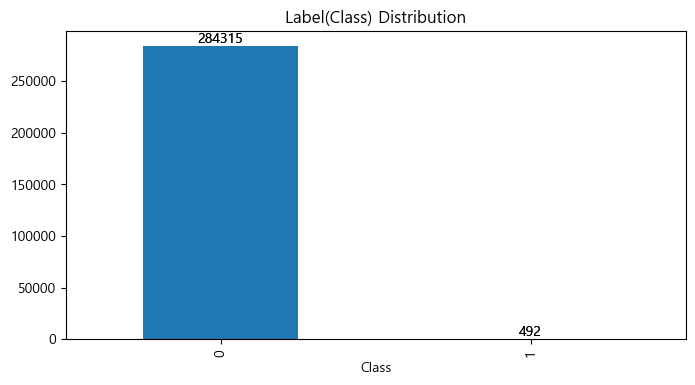

In [20]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=True)

In [21]:
# 2. Data전처리
# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)
df_scaled = pp.robustScaler(df)
# robutScaler : 이상치가 많은 데이터에 좋음

✅ 'Amount' 스케일링 완료 → 'Amount_scaled'
✅ 'Time' 스케일링 완료 → 'Time_scaled'

🗑️  원본 컬럼 제거: ['Amount', 'Time']

✅ 스케일링 완료: 2개 컬럼
   최종 shape: (284807, 31)


In [22]:
# Time 제거한 모델용 데이터프레임
df_model = df.drop(columns=['Time'])

X_features, y_target = pp.split_features_target(df_model)
# cols=None, target_col='Class' 기본값

In [23]:
# data_split은 내부에서 test_size/random_state/stratify=y_target을 이미 쓰고 있다
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [8]:
# 모델 생성

# 1) 기본
dt_basic = DecisionTreeClassifier(
    criterion="gini",   # 분할 기준 (gini, entropy)
    max_depth=None,     # 트리 최대 깊이 (None이면 제한 없음)
    random_state=23
)

# 2) class_weight 적용 버전
dt_balanced = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    class_weight='balanced',
    random_state=23
)

uu.get_model_train_eval(dt_basic,   'DT_notScaled_basic',   X_train, X_test, y_train, y_test)
uu.get_model_train_eval(dt_balanced,'DT_notScaled_balanced',X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\DT_notScaled_basic.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.391320943832397
✓ 모델 저장 완료: ../models\DT_notScaled_balanced.pkl
  파일 크기: 0.04 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8671, 정확도: 0.9990, 정밀도: 0.6990, 재현율: 0.7347, F1: 0.7164
오차행렬:
[[56833    31]
 [   26    72]]
실행 시간: 9.330060720443726


In [ ]:
# 1. 왜 class_weight 달았더니 더 나빠졌을까?

# class_weight='balanced'의 목적은:

# “소수 클래스(사기)를 더 중요하게 보고,
# 이걸 틀리면 더 큰 패널티를 주자” 인데,
# 이게 항상 성능↑을 보장하는 건 아니야.

# 트리 입장에서는
# 이미 기본 세팅에서 “나름 괜찮은 분할”을 하고 있었는데

# 갑자기 소수 클래스 비중을 높여버리면
# → 학습이 조금 더 요동치고
# → 과적합/분할 방향이 애매하게 바뀌면서
# 전체 AUC나 실제 재현율이 오히려 떨어질 수도 있음.

# 특히 지금 같은 단일 DecisionTree는
# 원래도 variance(변동성)가 큰 모델이라
# class_weight 조금만 바꿔도 결과가 꽤 달라질 수 있어.

# 요약하면:

# class_weight는 **“성능을 낮추는 옵션”이 아니라
# “불균형을 보정하는 옵션”**인데,
# 결과 성능이 좋아질지/나빠질지는 모델·데이터·파라미터에 따라 다르다.

# 이번엔 우연히 basic 세팅이 더 잘 맞아떨어진 케이스라고 볼 수 있어.

In [9]:
# GradientBoostingClassifier
gb_basic = GradientBoostingClassifier(
    n_estimators=100,      # 트리 개수
    learning_rate=0.1,     # 학습률
    max_depth=3,           # 개별 트리 깊이
    random_state=23
)

uu.get_model_train_eval(gb_basic,'GB_notScaled_basic',X_train,X_test,y_train,y_test)

✓ 모델 저장 완료: ../models\GB_notScaled_basic.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 300.39953565597534


In [16]:
# MLPClassifier
# 반드시 스케일링이 필요한 모델

# 1) 스케일링이 필요한 모델용 피처 리스트 (Class, Time 이미 없음)
all_feature_cols = X_train.columns.tolist()

# 2) StandardScaler로 전체 피처 스케일링
X_train_scaled, X_test_scaled, scaler = pp.scale_selected_columns(
    X_train,
    X_test,
    columns=all_feature_cols
)

mlp_basic = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=50,
    random_state=23
)

uu.get_model_train_eval(
    mlp_basic,
    'MLP_scaled_basic',
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

✓ 모델 저장 완료: ../models\MLP_scaled_basic.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9586, 정확도: 0.9994, 정밀도: 0.8144, 재현율: 0.8061, F1: 0.8103
오차행렬:
[[56846    18]
 [   19    79]]
실행 시간: 23.751501083374023


In [ ]:
# 1. 왜 MLP는 스케일링이 필수급이냐?

# 지난 대화에서 이미 한 번 말했었는데:

# DecisionTree / GB 같은 트리 모델은 스케일에 둔감
# 하지만 SVM, MLP, LinearRegression 같은 애들은
# 피처 스케일이 크게 다르면
# 경사하강 / 최적화가 불안정해지고
# 학습이 제대로 안 되거나,
# 일부 피처만 과하게 영향을 주거나,
# max_iter 안에 수렴을 못 해서 warning만 잔뜩 뜰 수 있음

# 그래서 MLP는 무조건 StandardScaler나 RobustScaler 이후에 쓰는 게 정석이야.

In [17]:
# LinearRegression은 회귀 모델이라 predict_proba가 없음.
# → get_model_train_eval에 그냥 넣으면 에러 난다.

# LinearRegression baseline (scaled 데이터 사용 권장)
lin_basic = LinearRegression(n_jobs=-1)
start_time = time.time()

# 스케일링 쪽이 수치적으로 안정적이라, MLP와 같은 X_train_scaled 사용을 추천
lin_basic.fit(X_train_scaled, y_train)

# 모델 저장 (../models 폴더)
mu.save_model(lin_basic, 'LR_scaled_basic')

# 연속값 예측 (0~1 바깥도 나올 수 있음)
y_score = lin_basic.predict(X_test_scaled)

# 0.5 기준으로 분류 라벨 생성
y_pred = (y_score >= 0.5).astype(int)

exec_time = time.time() - start_time

# 기존 get_clf_eval 재사용 (y_score를 "pred_proba" 자리에 넣음)
uu.get_clf_eval(
    y_test,
    y_pred,
    y_score,
    model_name='LinearR_scaled_basic',
    exec_time=exec_time
)


✓ 모델 저장 완료: ../models\LR_scaled_basic.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9696, 정확도: 0.9990, 정밀도: 0.8621, 재현율: 0.5102, F1: 0.6410
오차행렬:
[[56856     8]
 [   48    50]]
실행 시간: 0.15444254875183105


In [24]:
# 1) 기본 SVM (RBF 커널)
svm_basic = SVC(
    kernel='rbf',          # 기본 RBF 커널
    C=1.0,
    gamma='scale',
    probability=True,      # predict_proba 사용하려면 필수
    random_state=23
)

# 2) class_weight 적용 버전
svm_balanced = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,      # 이것도 여전히 필요
    class_weight='balanced',
    random_state=23
)

# 평가 (스케일된 데이터로!)
uu.get_model_train_eval(
    svm_basic,
    'SVM_scaled_basic',
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

uu.get_model_train_eval(
    svm_balanced,
    'SVM_scaled_balanced',
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

✓ 모델 저장 완료: ../models\SVM_scaled_basic.pkl
  파일 크기: 0.79 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9317, 정확도: 0.9994, 정밀도: 0.9452, 재현율: 0.7041, F1: 0.8070
오차행렬:
[[56860     4]
 [   29    69]]
실행 시간: 2016.6271109580994
✓ 모델 저장 완료: ../models\SVM_scaled_balanced.pkl
  파일 크기: 1.32 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9630, 정확도: 0.9970, 정밀도: 0.3348, 재현율: 0.7551, F1: 0.4639
오차행렬:
[[56717   147]
 [   24    74]]
실행 시간: 1629.5676057338715


In [25]:
# 공통 헬퍼 함수

def run_sampling_experiments_for_model(
    base_model,
    base_name,
    X_train,
    X_test,
    y_train,
    y_test,
    random_state=23
):
    """
    하나의 모델에 대해
    - 언더샘플링
    - 오버샘플링(SMOTE)
    - 혼합(SMOTETomek)
    세 가지 버전을 순차적으로 학습/평가하는 헬퍼 함수
    """

    # 1) 언더샘플링
    X_under, y_under = ds.undersampling_RUS(
        X_train, y_train, random_state=random_state
    )
    model_under = base_model.__class__(**base_model.get_params())
    uu.get_model_train_eval(
        model_under,
        f"{base_name}_under",
        X_under,
        X_test,
        y_under,
        y_test,
    )

    # 2) 오버샘플링 (SMOTE)
    X_smote, y_smote = ds.oversampling_smote(
        X_train, y_train, random_state=random_state
    )
    model_smote = base_model.__class__(**base_model.get_params())
    uu.get_model_train_eval(
        model_smote,
        f"{base_name}_smote",
        X_smote,
        X_test,
        y_smote,
        y_test,
    )

    # 3) 혼합 샘플링 (SMOTETomek)
    X_comb, y_comb = ds.combined_sampling(
        X_train, y_train, random_state=random_state
    )
    model_comb = base_model.__class__(**base_model.get_params())
    uu.get_model_train_eval(
        model_comb,
        f"{base_name}_combined",
        X_comb,
        X_test,
        y_comb,
        y_test,
    )

# train만 리샘플링하고,
# test는 항상 원본 X_test, y_test 그대로

In [ ]:
# 트리 계열 (스케일링 X) – DT, GB

# DecisionTree 기본 설정
dt_basic = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=23
)

# GradientBoosting 기본 설정
gb_basic = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=23
)

# === 샘플링 실험 호출 ===

# 1) DT: 언더/오버/혼합
run_sampling_experiments_for_model(
    dt_basic,
    "DT_notScaled",   # 결과 파일 prefix
    X_train,
    X_test,
    y_train,
    y_test,
)

# 2) GB: 언더/오버/혼합
run_sampling_experiments_for_model(
    gb_basic,
    "GB_notScaled",
    X_train,
    X_test,
    y_train,
    y_test,
)

In [ ]:
# 스케일링이 필요한 모델 – MLP, SVM, (LinearRegression)

mlp_basic = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=50,
    random_state=23
)

run_sampling_experiments_for_model(
    mlp_basic,
    "MLP_scaled",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
)

In [ ]:
# LinearRegression 함수 선언

def train_eval_linear_regression(
    X_train, y_train,
    X_test,  y_test,
    model_name: str
):
    """
    LinearRegression을 학습시키고,
    연속 예측값으로 AUC + 0.5 threshold 분류 성능을 평가
    """
    lr = LinearRegression(n_jobs=-1)

    start_time = time.time()
    lr.fit(X_train, y_train)

    # 모델 저장
    mu.save_model(lr, model_name)

    # 연속값 예측 (0~1 바깥도 나올 수 있음)
    y_score = lr.predict(X_test)

    # 0.5 기준으로 0/1 분류 라벨
    y_pred = (y_score >= 0.5).astype(int)

    exec_time = time.time() - start_time

    # 기존 clf_eval 재사용 (y_score를 "확률" 자리에 넣어도 AUC 계산 가능)
    uu.get_clf_eval(
        y_test,
        y_pred,
        y_score,
        model_name=model_name,
        exec_time=exec_time
    )

In [ ]:
# SVM -> 시간 엄청나게 걸리니까 나중에 다른 컴에서 하기
run_sampling_experiments_for_model(
    svm_basic,
    "SVM_scaled",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
)

In [ ]:
# 그래프 그리기 함수

def plot_sampling_metrics(model_name, sampling_methods, auc, prec, recall, f1):
    bar_width = 0.18
    x = np.arange(len(sampling_methods))

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_auc = ax.bar(x - 1.5*bar_width, auc, width=bar_width, label='AUC')
    bars_prec = ax.bar(x - 0.5*bar_width, prec, width=bar_width, label='정밀도')
    bars_recall = ax.bar(x + 0.5*bar_width, recall, width=bar_width, label='재현율')
    bars_f1 = ax.bar(x + 1.5*bar_width, f1, width=bar_width, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(sampling_methods, fontsize=11)

    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} 샘플링 평가 지표 비교 (정확도 제외)', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.legend(title='지표')

    def annotate(bars):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2,
                    h + 0.01,
                    f'{h:.3f}',
                    ha='center', va='bottom', fontsize=9)

    for bars in [bars_auc, bars_prec, bars_recall, bars_f1]:
        annotate(bars)

    plt.tight_layout()
    plt.show()


In [ ]:
# 그래프 그리기

# 샘플링 이름 (x축)
sampling_methods = ['Origin', 'Oversampled', 'Undersampled', 'Combined']

# 각 샘플링에서 나온 지표값을 직접 채워 넣기
#    ↓ 여기에 너가 실제로 얻은 수치를 넣으면 됨
auc_scores = [
    0.960,  # Origin
    0.958,  # Oversampled
    0.969,  # Undersampled
    0.958   # Combined
]

precision_scores = [
    0.059,  # Origin
    0.082,  # Oversampled
    0.089,  # Undersampled
    0.082   # Combined
]

recall_scores = [
    0.878,  # Origin
    0.878,  # Oversampled
    0.878,  # Undersampled
    0.878   # Combined
]

f1_scores = [
    0.111,  # Origin
    0.151,  # Oversampled
    0.155,  # Undersampled
    0.151   # Combined
]

plot_sampling_metrics(
    model_name='DecisionTree',
    sampling_methods=sampling_methods,
    auc=auc_scores,
    prec=precision_scores,
    recall=recall_scores,
    f1=f1_scores
)